# From opening an NCS area to an exploration discovery

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/ncs_area_opening_licensing_exploration_to_discovery.ipynb)

**A reproducible learning path through Norwegian resource governance, licence
access, regional exploration, prospect evaluation, drilling, discovery
evaluation, and the hand-off to field development.**

This notebook is the upstream companion to
[From seismic, samples, and petrophysics to an OPM Flow production
forecast](../reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb).
It also connects to the
[Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html).

The worked map, licence, prospect, volume, cost, and fluid data are
**deterministic synthetic teaching data**. They do not represent a real NCS
block, licence application, prospect, discovery, environmental assessment, or
investment case.

## Learning outcomes

After completing the notebook, you should be able to:

1. distinguish an **opened area**, announced acreage, a production licence,
   and an approved exploration well;
2. explain numbered rounds, Awards in Predefined Areas (APA),
   pre-qualification, licence groups, operatorship, and work obligations;
3. trace an exploration workflow from regional data through play, lead,
   prospect, wildcat, discovery, and appraisal;
4. use public map metadata and licensed seismic coverage without confusing
   data availability with subsurface quality;
5. keep geological chance, success-case volume, access, environmental
   constraints, and commercial value as separate quantities;
6. calculate play and prospect chance, probabilistic in-place and recoverable
   volumes, uncertainty sensitivities, and a transparent drill-screen;
7. use a hypothetical discovery-fluid sample in NeqSim to replace an
   analogue formation-volume assumption; and
8. assemble the discovery data package required by the next reservoir,
   well, SURF, facility, and production-forecast studies.

### Scope boundary

The notebook is educational. It is not legal advice, an authority submission,
an acreage nomination, a licence application, a drilling programme, an HSE or
environmental assessment, a reserves report, or a certified economic
evaluation. Current round documents and the terms of each production licence
govern real work.

## 0. Clean Colab setup

The released notebook was validated with **NeqSim 3.16.0**, Python 3.12, and
OpenJDK 17. The installation is only run in Google Colab; a prepared local
environment is left unchanged.

In [1]:
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.16.0",
            "numpy>=2.0",
            "pandas>=2.2",
            "matplotlib>=3.8",
        ],
        check=True,
    )

In [2]:
from importlib.metadata import version

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim.thermo import TPflash
from neqsim.thermo import fluid

SEED = 20260730
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 120,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.frameon": True,
    }
)

runtime = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "Matplotlib": matplotlib.__version__,
        "Random seed": SEED,
    },
    name="validated runtime",
)
runtime.to_frame()

,validated runtime
NeqSim,3.16.0
Python,3.12.13
NumPy,2.5.1
pandas,3.0.5
Matplotlib,3.11.1
Random seed,20260730


# Part I — Society opens an area before companies can receive acreage

Norway owns the petroleum resources on the continental shelf. A company
cannot turn an attractive regional map into a drilling right by itself.

Under [Petroleum Act section 3-1](https://www.sodir.no/en/regulations/acts/act-29-november-1996-no2.-72-relating-to-petroleum-activities),
opening a new area requires evaluation of environmental, commercial,
pollution-risk, economic, and social effects, consultation, and political
consideration. The
[Petroleum Regulations sections 6a–6c](https://www.sodir.no/en/regulations/regulations/petroleum-activities/)
describe the impact-assessment programme, consultation, assessment content,
and proposal to the Storting.

An opening decision makes later licensing legally possible. It does **not**
award a company acreage and does not approve a well.

In [3]:
opening_steps = pd.DataFrame(
    [
        (
            "Knowledge basis",
            "Authorities and research bodies",
            "Geology, environment, fisheries, other ocean use, value and risk",
            "Evidence for an opening study",
        ),
        (
            "Assessment programme",
            "Ministry of Energy",
            "Scope, alternatives, methods and mapped area",
            "Draft programme for consultation",
        ),
        (
            "Impact assessment",
            "Ministry-led process",
            "Environmental, social, economic and coexistence consequences",
            "Decision basis and mitigation options",
        ),
        (
            "Public consultation",
            "Authorities, organisations and public",
            "New evidence, interests, conflicts and proposed conditions",
            "Consultation record",
        ),
        (
            "Political decision",
            "Storting and government",
            "Whether and on which high-level conditions to open",
            "Opened, partly opened, deferred or not opened",
        ),
        (
            "Later licensing rounds",
            "Ministry of Energy",
            "Selected available blocks in an opened area",
            "Licensing-round invitation",
        ),
    ],
    columns=["Stage", "Primary actor", "Question", "Output"],
)
opening_steps

,Stage,Primary actor,Question,Output
0,Knowledge basis,Authorities and research bodies,"Geology, environment, fisheries, other ocean u...",Evidence for an opening study
1,Assessment programme,Ministry of Energy,"Scope, alternatives, methods and mapped area",Draft programme for consultation
2,Impact assessment,Ministry-led process,"Environmental, social, economic and coexistenc...",Decision basis and mitigation options
3,Public consultation,"Authorities, organisations and public","New evidence, interests, conflicts and propose...",Consultation record
4,Political decision,Storting and government,Whether and on which high-level conditions to ...,"Opened, partly opened, deferred or not opened"
5,Later licensing rounds,Ministry of Energy,Selected available blocks in an opened area,Licensing-round invitation


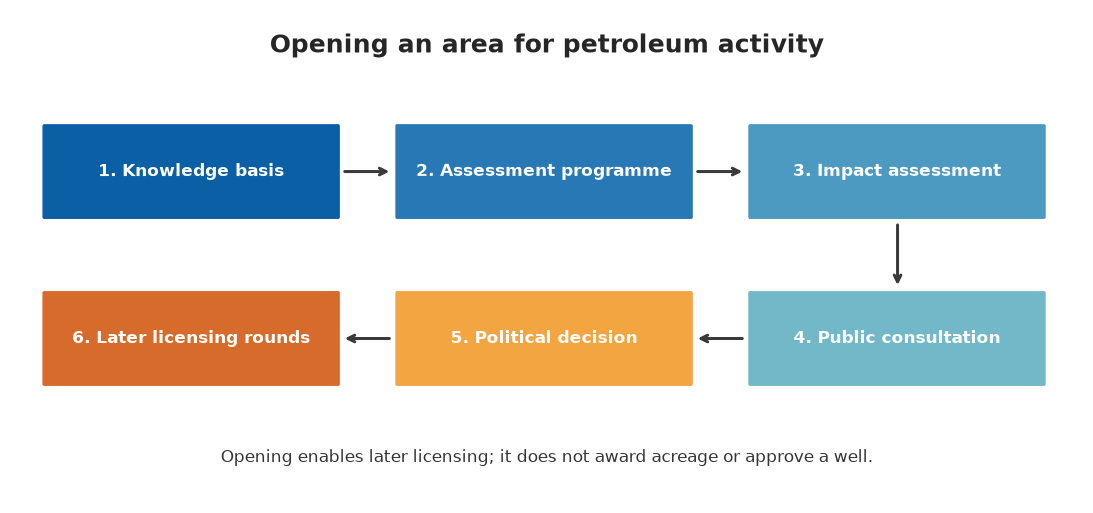

In [4]:
figure, axis = plt.subplots(figsize=(11.5, 5.3))
axis.set_xlim(0, 10)
axis.set_ylim(0, 4.4)
axis.axis("off")

colors = ["#0B5FA5", "#2878B5", "#4C9AC2", "#73B8C8", "#F2A541", "#D66B2C"]
positions = [
    (0.3, 2.55),
    (3.6, 2.55),
    (6.9, 2.55),
    (6.9, 1.05),
    (3.6, 1.05),
    (0.3, 1.05),
]
box_width = 2.75
box_height = 0.82

for index, row in opening_steps.iterrows():
    x_position, y_position = positions[index]
    box = FancyBboxPatch(
        (x_position, y_position),
        box_width,
        box_height,
        boxstyle="round,pad=0.025",
        linewidth=1.2,
        edgecolor="white",
        facecolor=colors[index],
    )
    axis.add_patch(box)
    axis.text(
        x_position + box_width / 2.0,
        y_position + box_height / 2.0,
        f"{index + 1}. {row['Stage']}",
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        wrap=True,
    )

arrow_pairs = [
    ((3.08, 2.96), (3.56, 2.96)),
    ((6.38, 2.96), (6.86, 2.96)),
    ((8.28, 2.51), (8.28, 1.91)),
    ((6.86, 1.46), (6.38, 1.46)),
    ((3.56, 1.46), (3.08, 1.46)),
]
for start, end in arrow_pairs:
    axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "color": "#3A3A3A", "lw": 1.8},
    )

axis.text(
    5.0,
    4.03,
    "Opening an area for petroleum activity",
    ha="center",
    fontsize=15,
    fontweight="bold",
)
axis.text(
    5.0,
    0.35,
    "Opening enables later licensing; it does not award acreage or approve a well.",
    ha="center",
    fontsize=10,
    color="#333333",
)
plt.show()

## Four legal and technical states that must not be conflated

The same polygon can appear differently on political, legal, licensing,
seismic-coverage, play-fairway, and prospect maps.

In [5]:
area_states = pd.DataFrame(
    [
        (
            "Opened area",
            "Petroleum licensing may later occur",
            "No company-specific exclusive right",
            "Opening decision and applicable management conditions",
        ),
        (
            "Announced acreage",
            "Applications are invited for selected available blocks",
            "No award is guaranteed",
            "Current round invitation, maps and application guidance",
        ),
        (
            "Production licence",
            "Licence group has exclusive petroleum rights in the licence area",
            "Rights remain subject to terms and work obligations",
            "Licence document, agreements, interests and operator",
        ),
        (
            "Approved exploration well",
            "A specified well can be drilled after required approvals",
            "Not a general permission to drill anywhere",
            "Licence decision, well consent, drilling permit and HSE basis",
        ),
    ],
    columns=["State", "What it enables", "What it does not mean", "Check"],
)
area_states

,State,What it enables,What it does not mean,Check
0,Opened area,Petroleum licensing may later occur,No company-specific exclusive right,Opening decision and applicable management con...
1,Announced acreage,Applications are invited for selected availabl...,No award is guaranteed,"Current round invitation, maps and application..."
2,Production licence,Licence group has exclusive petroleum rights i...,Rights remain subject to terms and work obliga...,"Licence document, agreements, interests and op..."
3,Approved exploration well,A specified well can be drilled after required...,Not a general permission to drill anywhere,"Licence decision, well consent, drilling permi..."


# Part II — How companies obtain and retain access

The [Norwegian Offshore Directorate](https://www.sodir.no/en/facts/production-licences/licensing-rounds/)
describes two principal round types:

- **numbered rounds** for opened frontier acreage, normally less explored; and
- annual **Awards in Predefined Areas (APA)** for mature acreage with more
  geological knowledge and infrastructure.

A new participant must be pre-qualified as licensee or operator. Operators
face broader requirements because they manage activities on behalf of the
licence group. See the Directorate's
[requirements for new players](https://www.sodir.no/en/facts/production-licences/pre-qualification/requirements-for-new-players-on-the-norwegian-continental-shelf/).

The current invitation controls a real application. For example, the
[APA 2026 invitation](https://www.sodir.no/en/facts/production-licences/licensing-rounds/apa-2026/invitation-to-apply-for-petroleum-production-licence/)
states the qualification basis, award criteria, application contents, licence
group expectations, work obligations, and block-specific conditions. Those
details change; this notebook models the stable logic, not a substitute
application.

In [6]:
round_comparison = pd.DataFrame(
    [
        (
            "Numbered round",
            "Opened frontier acreage",
            "Normally less subsurface control and infrastructure",
            "Regional play concept, large upside and uncertainty",
            "Current numbered-round invitation",
        ),
        (
            "APA",
            "Predefined mature acreage",
            "More wells, seismic, known plays and nearby infrastructure",
            "Time-critical resources, near-field and remaining play potential",
            "Current annual APA invitation",
        ),
    ],
    columns=[
        "Route",
        "Typical acreage",
        "Information setting",
        "Application emphasis",
        "Authoritative source",
    ],
)
round_comparison

,Route,Typical acreage,Information setting,Application emphasis,Authoritative source
0,Numbered round,Opened frontier acreage,Normally less subsurface control and infrastru...,"Regional play concept, large upside and uncert...",Current numbered-round invitation
1,APA,Predefined mature acreage,"More wells, seismic, known plays and nearby in...","Time-critical resources, near-field and remain...",Current annual APA invitation


## What the authorities evaluate

Licence awards are not auctions based only on the highest volume estimate.
Current invitations emphasize:

- the applicant's geological understanding and exploration plan;
- anticipated reservoir and development solutions and good area solutions;
- relevant technical competence and operational experience;
- financial capacity and past licence performance;
- a capable licence group and an appointed operator; and
- a credible, time-bounded work programme.

A production licence creates a joint venture governed by the licence and
petroleum agreements. Petoro may hold the State's Direct Financial Interest
(SDFI). The operator manages activity, but partners retain licence
responsibilities and participate in decisions.

In [7]:
application_package = pd.DataFrame(
    [
        ("Company qualification", "Licensee/operator capability", "Gate"),
        ("Regional geological model", "Basin, play and uncertainty understanding", "Merit"),
        ("Block evaluation", "Leads, prospects, chance and volumes", "Merit"),
        ("Data plan", "Reprocessing, purchase, acquisition and interpretation", "Merit"),
        ("Work programme", "Decision gates, timing and drill-or-drop logic", "Commitment"),
        ("Development thinking", "Possible evacuation and area solutions", "Merit"),
        ("HSE and coexistence", "Capability and block-specific constraints", "Gate"),
        ("Financial capacity", "Ability to fund exploration and possible development", "Gate"),
        ("Licence group", "Roles, interests and operator competence", "Structure"),
    ],
    columns=["Application element", "Purpose", "Evaluation role"],
)
application_package

,Application element,Purpose,Evaluation role
0,Company qualification,Licensee/operator capability,Gate
1,Regional geological model,"Basin, play and uncertainty understanding",Merit
2,Block evaluation,"Leads, prospects, chance and volumes",Merit
3,Data plan,"Reprocessing, purchase, acquisition and interp...",Merit
4,Work programme,"Decision gates, timing and drill-or-drop logic",Commitment
5,Development thinking,Possible evacuation and area solutions,Merit
6,HSE and coexistence,Capability and block-specific constraints,Gate
7,Financial capacity,Ability to fund exploration and possible devel...,Gate
8,Licence group,"Roles, interests and operator competence",Structure


## Licence work obligations: learn, decide, drill or relinquish

The Directorate notes that an exploration-period licence commonly has a
binding, phased work programme. A first phase may require seismic work and a
later gate may be **drill or drop**. Exact obligations and deadlines are
licence-specific; see
[Work commitments](https://www.sodir.no/en/regulations/reporting_and_applications/work-commitments/).

The synthetic schedule below starts at licence award. It is a teaching
example, not a standard duration.

In [8]:
licence_schedule = pd.DataFrame(
    [
        ("Licence award and organisation", 0.0, 0.4, "Set up JV, governance and data room"),
        ("Regional interpretation", 0.2, 1.0, "Basin, play and common-risk segments"),
        ("Reprocess or license seismic", 0.5, 1.4, "Improve imaging and depth uncertainty"),
        ("Lead-to-prospect maturation", 1.0, 2.0, "Closure, charge, reservoir, seal and volumes"),
        ("Drill-or-drop decision", 2.0, 2.2, "Commit to well or relinquish as required"),
        ("Well planning and approvals", 2.1, 3.0, "Site, trajectory, basis and consents"),
        ("Wildcat and evaluation", 3.0, 3.3, "Drill, acquire data and classify result"),
        ("Appraise or exit", 3.3, 4.5, "Reduce discovery uncertainty or stop"),
    ],
    columns=["Activity", "Start year", "End year", "Decision purpose"],
)
licence_schedule["Duration"] = (
    licence_schedule["End year"] - licence_schedule["Start year"]
)
licence_schedule

,Activity,Start year,End year,Decision purpose,Duration
0,Licence award and organisation,0.0,0.4,"Set up JV, governance and data room",0.4
1,Regional interpretation,0.2,1.0,"Basin, play and common-risk segments",0.8
2,Reprocess or license seismic,0.5,1.4,Improve imaging and depth uncertainty,0.9
3,Lead-to-prospect maturation,1.0,2.0,"Closure, charge, reservoir, seal and volumes",1.0
4,Drill-or-drop decision,2.0,2.2,Commit to well or relinquish as required,0.2
5,Well planning and approvals,2.1,3.0,"Site, trajectory, basis and consents",0.9
6,Wildcat and evaluation,3.0,3.3,"Drill, acquire data and classify result",0.3
7,Appraise or exit,3.3,4.5,Reduce discovery uncertainty or stop,1.2


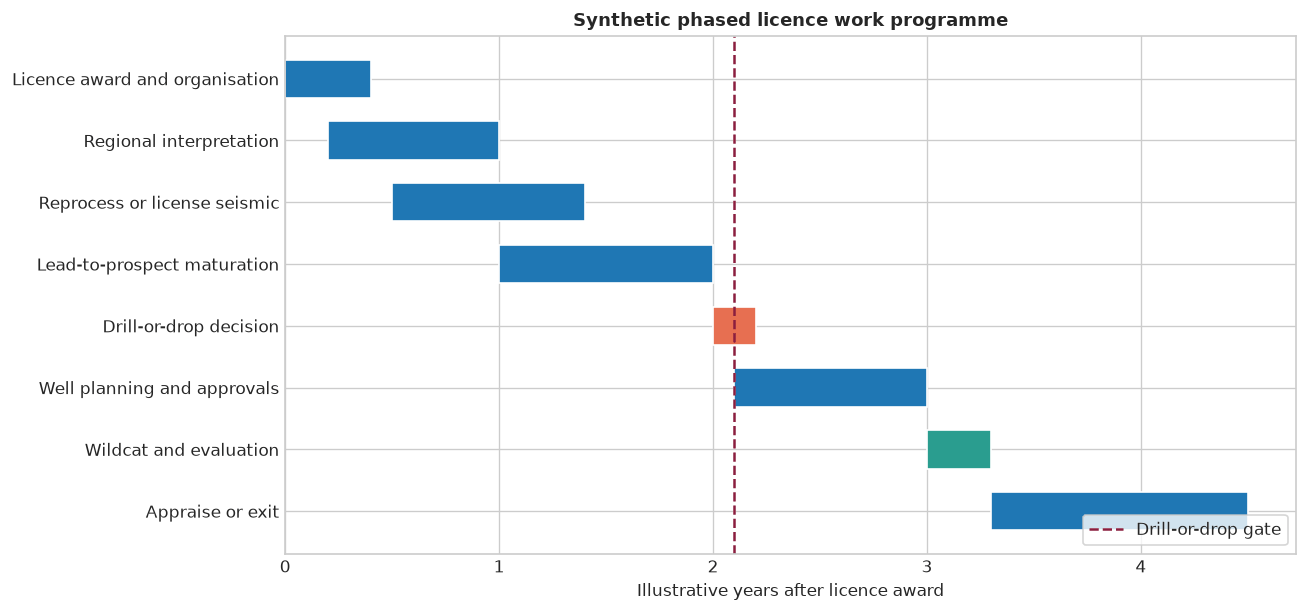

In [9]:
figure, axis = plt.subplots(figsize=(11, 5.2))

for row_index, row in licence_schedule.iterrows():
    color = "#1F77B4"
    if "decision" in row["Activity"].lower():
        color = "#E76F51"
    if "wildcat" in row["Activity"].lower():
        color = "#2A9D8F"
    axis.barh(
        row_index,
        row["Duration"],
        left=row["Start year"],
        height=0.62,
        color=color,
        edgecolor="white",
    )

axis.set_yticks(range(len(licence_schedule)))
axis.set_yticklabels(licence_schedule["Activity"])
axis.invert_yaxis()
axis.set_xlabel("Illustrative years after licence award")
axis.set_title("Synthetic phased licence work programme")
axis.axvline(2.1, color="#8B1E3F", linestyle="--", label="Drill-or-drop gate")
axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Part III — The exploration evidence chain

An exploration team normally moves through nested scales:

**basin → petroleum system → play → common-risk segment → lead → prospect →
well target → discovery → appraisal**

A *play* shares essential geological controls. A *lead* is a possible trap that
still needs material definition. A *prospect* is sufficiently mapped and
risked to be a candidate for drilling. A *wildcat well* tests a prospect. An
*appraisal well* establishes the extent and size of an existing discovery; see
the Directorate's [well definitions](https://www.sodir.no/en/facts/wells/well-definitions/).

In [10]:
evidence_chain = pd.DataFrame(
    [
        (
            "Basin",
            "Is there a sedimentary basin and viable burial history?",
            "Regional geophysics and geology",
        ),
        (
            "Petroleum system",
            "Can source, migration, reservoir, seal and timing work?",
            "Wells, geochemistry and basin modelling",
        ),
        (
            "Play",
            "Where do shared petroleum-system elements coincide?",
            "Play maps and common-risk segments",
        ),
        (
            "Lead",
            "Is there a potentially closed accumulation?",
            "2D/3D interpretation and analogues",
        ),
        (
            "Prospect",
            "Is the target defined, risked and drillable?",
            "Depth map, chance, volume and well basis",
        ),
        (
            "Wildcat",
            "Are movable hydrocarbons present?",
            "Logs, pressure, samples, cores and tests",
        ),
        (
            "Discovery",
            "What was found and what remains uncertain?",
            "Discovery evaluation and preliminary volumes",
        ),
        (
            "Appraisal",
            "What extent, connectivity and deliverability exist?",
            "Appraisal wells and dynamic data",
        ),
    ],
    columns=["Scale", "Primary question", "Typical evidence"],
)
evidence_chain

,Scale,Primary question,Typical evidence
0,Basin,Is there a sedimentary basin and viable burial...,Regional geophysics and geology
1,Petroleum system,"Can source, migration, reservoir, seal and tim...","Wells, geochemistry and basin modelling"
2,Play,Where do shared petroleum-system elements coin...,Play maps and common-risk segments
3,Lead,Is there a potentially closed accumulation?,2D/3D interpretation and analogues
4,Prospect,"Is the target defined, risked and drillable?","Depth map, chance, volume and well basis"
5,Wildcat,Are movable hydrocarbons present?,"Logs, pressure, samples, cores and tests"
6,Discovery,What was found and what remains uncertain?,Discovery evaluation and preliminary volumes
7,Appraisal,"What extent, connectivity and deliverability e...",Appraisal wells and dynamic data


## Public and licensed data are complementary

Useful starting points include:

- [SODIR Open data](https://www.sodir.no/en/facts/data-and-analyses/open-data/)
  for licences, APA acreage, wells, discoveries, facilities, surveys and
  pipelines in CSV or shapefile form;
- [FactPages](https://factpages.sodir.no/) and
  [FactMaps](https://factmaps.sodir.no/) for tabular and geographic context;
- [released data through Diskos](https://www.sodir.no/en/facts/data-and-analyses/release-of-data/access-to-released-data/)
  for released well, seismic and production data;
- the Directorate's [play descriptions](https://www.sodir.no/en/facts/plays/)
  and resource reports; and
- bathymetry, environment, fisheries, infrastructure, and management-plan
  sources appropriate to the question.

**Multi-client seismic (MCS) caution:** public survey outlines show where data
were acquired, but interpreted cubes, amplitudes, velocity products, and
commercial MCS rights can remain licensed. Coverage is not permission to
redistribute data. Verify ownership, confidentiality, release status,
entitlements, coordinate reference system, processing vintage, polarity, and
licence terms before use.

In [11]:
source_register = pd.DataFrame(
    [
        (
            "Licence and APA polygons",
            "SODIR open data / FactMaps",
            "Legal and round context",
            "Public metadata; verify current date",
        ),
        (
            "Well and discovery metadata",
            "SODIR FactPages / open data",
            "Calibration and analogue screening",
            "Public metadata; released content varies",
        ),
        (
            "Released well and seismic data",
            "Diskos public/member access",
            "Interpretation and regional calibration",
            "Access and release rules apply",
        ),
        (
            "MCS survey coverage and products",
            "Seismic vendor / entitled data room",
            "Imaging, attributes and depth conversion",
            "Commercial licence and confidentiality apply",
        ),
        (
            "Facilities and main pipelines",
            "SODIR open data",
            "Access and evacuation context",
            "Distance is not spare capacity",
        ),
        (
            "Environment and fisheries",
            "Relevant Norwegian public authorities",
            "Coexistence and constraints",
            "Use authoritative current layers",
        ),
        (
            "Field-development learning chain",
            "NeqSim Field Development and Operations book",
            "Discovery-to-production integration",
            "Educational source",
        ),
    ],
    columns=["Dataset", "Example source", "Use", "Rights / interpretation note"],
)
source_register

,Dataset,Example source,Use,Rights / interpretation note
0,Licence and APA polygons,SODIR open data / FactMaps,Legal and round context,Public metadata; verify current date
1,Well and discovery metadata,SODIR FactPages / open data,Calibration and analogue screening,Public metadata; released content varies
2,Released well and seismic data,Diskos public/member access,Interpretation and regional calibration,Access and release rules apply
3,MCS survey coverage and products,Seismic vendor / entitled data room,"Imaging, attributes and depth conversion",Commercial licence and confidentiality apply
4,Facilities and main pipelines,SODIR open data,Access and evacuation context,Distance is not spare capacity
5,Environment and fisheries,Relevant Norwegian public authorities,Coexistence and constraints,Use authoritative current layers
6,Field-development learning chain,NeqSim Field Development and Operations book,Discovery-to-production integration,Educational source


## A reusable loader contract

Real files have changing columns, encodings, coordinate systems, and dates.
The loader therefore requires explicit columns and records provenance instead
of silently guessing. It accepts a local file or an entitled URL.

In [12]:
def load_tabular_map_data(
    source,
    required_columns,
    source_name,
    retrieved_date,
    coordinate_reference_system,
):
    # Load a CSV and attach an auditable provenance record.
    frame = pd.read_csv(source)
    missing_columns = [
        column for column in required_columns if column not in frame.columns
    ]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    provenance = {
        "source_name": source_name,
        "source": str(source),
        "retrieved_date": retrieved_date,
        "coordinate_reference_system": coordinate_reference_system,
        "row_count": len(frame),
    }
    return frame, provenance


loader_contract = pd.Series(
    {
        "Required before overlay": "CRS, units, geometry validity and date",
        "Required before interpretation": "vintage, processing and data rights",
        "Required before publication": "licence, attribution and confidentiality",
        "Notebook execution": "uses synthetic offline layers below",
    },
    name="map-data contract",
)
loader_contract.to_frame()

,map-data contract
Required before overlay,"CRS, units, geometry validity and date"
Required before interpretation,"vintage, processing and data rights"
Required before publication,"licence, attribution and confidentiality"
Notebook execution,uses synthetic offline layers below


# Part IV — Build a synthetic play-fairway and MCS-coverage screen

The next model deliberately uses local east/north coordinates in kilometres.
It is not located on the NCS. Smooth synthetic fields stand in for evidence
maps produced by specialists:

- mature source and effective migration;
- reservoir presence and quality;
- trap and seal effectiveness;
- seismic/data maturity;
- water depth and infrastructure distance; and
- an environmental/coexistence sensitivity indicator.

Geological chance is calculated only from geological factors. Access and
environmental indicators remain separate decision axes.

In [13]:
x_km = np.linspace(0.0, 240.0, 121)
y_km = np.linspace(0.0, 180.0, 91)
x_grid, y_grid = np.meshgrid(x_km, y_km)


def gaussian_field(x_center, y_center, x_scale, y_scale):
    x_term = ((x_grid - x_center) / x_scale) ** 2
    y_term = ((y_grid - y_center) / y_scale) ** 2
    return np.exp(-0.5 * (x_term + y_term))


def bounded(field):
    return np.clip(field, 0.02, 0.98)


source_chance = bounded(
    0.12
    + 0.72 * gaussian_field(75.0, 108.0, 68.0, 55.0)
    + 0.20 * gaussian_field(205.0, 52.0, 45.0, 42.0)
)
reservoir_chance = bounded(
    0.10
    + 0.74 * gaussian_field(142.0, 105.0, 78.0, 44.0)
    + 0.12 * np.sin(x_grid / 29.0)
)
trap_chance = bounded(
    0.20
    + 0.55 * gaussian_field(108.0, 72.0, 50.0, 38.0)
    + 0.25 * gaussian_field(192.0, 126.0, 38.0, 32.0)
)
seal_chance = bounded(
    0.44
    + 0.36 * gaussian_field(126.0, 98.0, 110.0, 80.0)
    - 0.20 * gaussian_field(218.0, 28.0, 36.0, 24.0)
)

three_d_coverage = (
    ((x_grid > 35.0) & (x_grid < 118.0) & (y_grid > 48.0) & (y_grid < 144.0))
    | ((x_grid > 154.0) & (x_grid < 222.0) & (y_grid > 82.0) & (y_grid < 164.0))
)
line_density = 0.20 + 0.25 * (np.sin(x_grid / 18.0) ** 2)
data_maturity = bounded(
    line_density
    + 0.46 * three_d_coverage.astype(float)
    + 0.18 * gaussian_field(55.0, 38.0, 35.0, 28.0)
)

water_depth_m = 110.0 + 2.6 * x_grid + 1.8 * y_grid
infrastructure_x_km = 26.0
infrastructure_y_km = 24.0
distance_to_infrastructure_km = np.hypot(
    x_grid - infrastructure_x_km,
    y_grid - infrastructure_y_km,
)
environmental_sensitivity = bounded(
    0.08
    + 0.75 * gaussian_field(44.0, 158.0, 36.0, 24.0)
    + 0.58 * gaussian_field(210.0, 38.0, 30.0, 26.0)
)

synthetic_layers = {
    "Mature source / migration chance": source_chance,
    "Reservoir chance": reservoir_chance,
    "Trap chance": trap_chance,
    "Seal chance": seal_chance,
    "Data maturity": data_maturity,
    "Water depth (m)": water_depth_m,
    "Distance to infrastructure (km)": distance_to_infrastructure_km,
    "Environmental sensitivity indicator": environmental_sensitivity,
}

pd.Series(
    {
        "Grid cells": x_grid.size,
        "East extent (km)": x_km.max(),
        "North extent (km)": y_km.max(),
        "Synthetic 3D coverage fraction": three_d_coverage.mean(),
    },
    name="synthetic map",
).to_frame()

,synthetic map
Grid cells,11011.000000
East extent (km),240.000000
North extent (km),180.000000
Synthetic 3D coverage fraction,0.294887


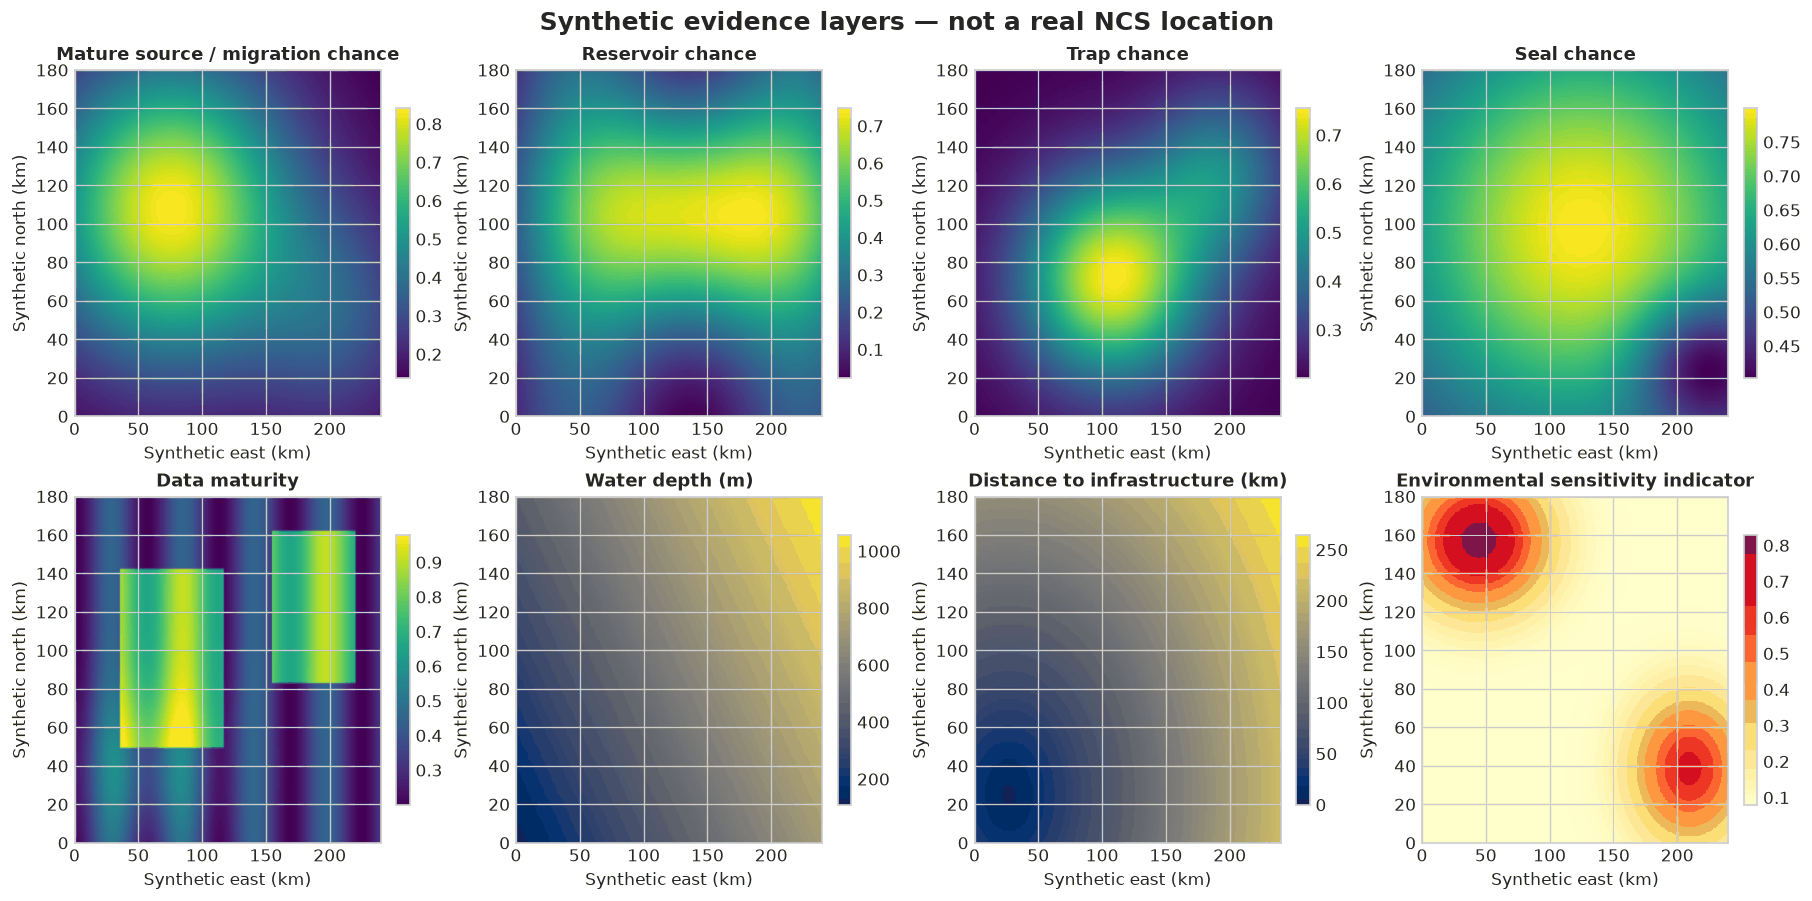

In [14]:
figure, axes = plt.subplots(2, 4, figsize=(15, 7.4), constrained_layout=True)

for axis, (title, values) in zip(axes.ravel(), synthetic_layers.items()):
    color_map = "viridis"
    if "depth" in title.lower() or "distance" in title.lower():
        color_map = "cividis"
    if "environmental" in title.lower():
        color_map = "YlOrRd"

    image = axis.imshow(
        values,
        origin="lower",
        extent=[x_km.min(), x_km.max(), y_km.min(), y_km.max()],
        aspect="auto",
        cmap=color_map,
    )
    axis.set_title(title)
    axis.set_xlabel("Synthetic east (km)")
    axis.set_ylabel("Synthetic north (km)")
    figure.colorbar(image, ax=axis, shrink=0.78)

figure.suptitle(
    "Synthetic evidence layers — not a real NCS location",
    fontsize=15,
    fontweight="bold",
)
plt.show()

## Play probability and common-risk segments

The Directorate explains a simple play assessment using likelihoods for
**reservoir rock, trap, and source rock**, multiplied to form a play
probability. The map below follows that public teaching logic:

$$P_{\mathrm{play}}=P_{\mathrm{source}}P_{\mathrm{reservoir}}P_{\mathrm{trap}}$$

This product assumes the mapped factors are suitable conditional quantities.
If factors share evidence or depend on one another, multiplication of marginal
probabilities can double-count information. A dependency model or explicit
conditional probabilities are then required.

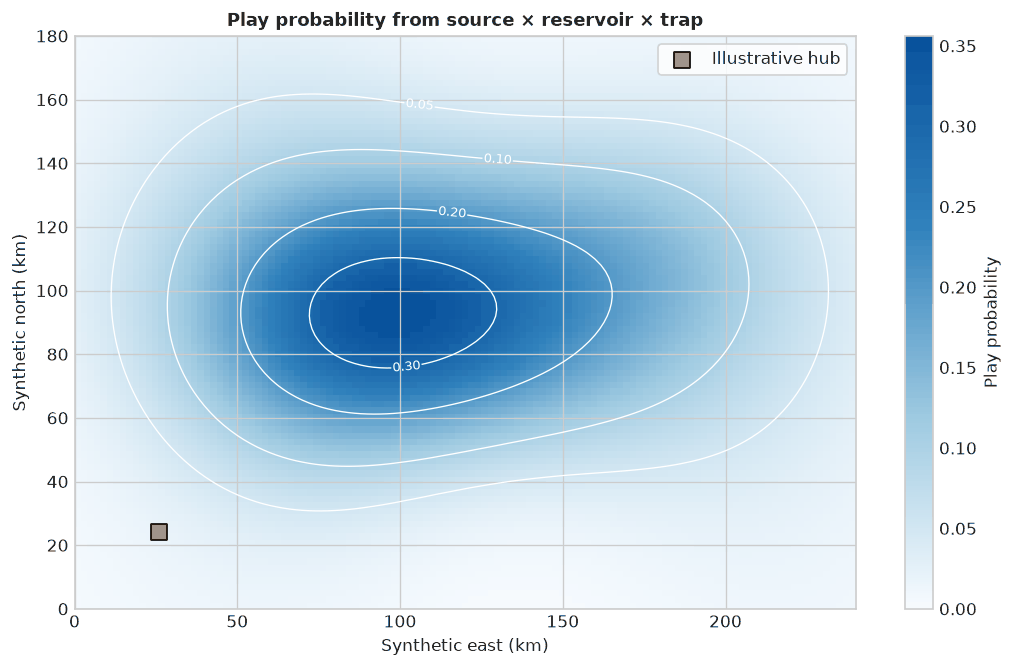

In [15]:
play_probability = source_chance * reservoir_chance * trap_chance

play_cmap = LinearSegmentedColormap.from_list(
    "play_chance",
    ["#F7FBFF", "#9ECAE1", "#3182BD", "#08519C"],
)

figure, axis = plt.subplots(figsize=(10.5, 6.2))
image = axis.imshow(
    play_probability,
    origin="lower",
    extent=[x_km.min(), x_km.max(), y_km.min(), y_km.max()],
    aspect="auto",
    cmap=play_cmap,
    vmin=0.0,
    vmax=max(0.35, play_probability.max()),
)
contours = axis.contour(
    x_grid,
    y_grid,
    play_probability,
    levels=[0.05, 0.10, 0.20, 0.30],
    colors="white",
    linewidths=0.8,
)
axis.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
axis.scatter(
    infrastructure_x_km,
    infrastructure_y_km,
    marker="s",
    s=90,
    color="#F4A261",
    edgecolor="black",
    label="Illustrative hub",
)
axis.set_xlabel("Synthetic east (km)")
axis.set_ylabel("Synthetic north (km)")
axis.set_title("Play probability from source × reservoir × trap")
axis.legend(loc="upper right")
figure.colorbar(image, ax=axis, label="Play probability")
plt.show()

## Mature leads without hiding the evidence

Five fictional leads sample different combinations of geology, data maturity,
water depth, infrastructure distance, and environmental sensitivity. A real
team would derive each factor from mapped evidence and document uncertainty,
alternative interpretations, calibration wells, and dependencies.

In [16]:
lead_locations = pd.DataFrame(
    [
        ("Aster", 104.0, 86.0),
        ("Boreal", 182.0, 132.0),
        ("Cirrus", 64.0, 138.0),
        ("Delta", 207.0, 57.0),
        ("Echo", 142.0, 54.0),
    ],
    columns=["Lead", "East (km)", "North (km)"],
)


def sample_grid(values, east_km, north_km):
    x_index = int(np.abs(x_km - east_km).argmin())
    y_index = int(np.abs(y_km - north_km).argmin())
    return float(values[y_index, x_index])


lead_rows = []
for _, lead in lead_locations.iterrows():
    east = lead["East (km)"]
    north = lead["North (km)"]
    lead_rows.append(
        {
            "Lead": lead["Lead"],
            "East (km)": east,
            "North (km)": north,
            "Play chance": sample_grid(play_probability, east, north),
            "Seal chance": sample_grid(seal_chance, east, north),
            "Data maturity": sample_grid(data_maturity, east, north),
            "Water depth (m)": sample_grid(water_depth_m, east, north),
            "Infrastructure distance (km)": sample_grid(
                distance_to_infrastructure_km,
                east,
                north,
            ),
            "Environmental indicator": sample_grid(
                environmental_sensitivity,
                east,
                north,
            ),
        }
    )

lead_screen = pd.DataFrame(lead_rows)
lead_screen["Geology indicator"] = (
    lead_screen["Play chance"] * lead_screen["Seal chance"]
)
lead_screen["Data gap"] = 1.0 - lead_screen["Data maturity"]
lead_screen["High-sensitivity flag"] = (
    lead_screen["Environmental indicator"] >= 0.70
)
lead_screen.round(3)

,Lead,East (km),North (km),Play chance,Seal chance,Data maturity,Water depth (m),Infrastructure distance (km),Environmental indicator,Geology indicator,Data gap,High-sensitivity flag
0,Aster,104.0,86.0,0.344,0.789,0.734,535.2,99.639,0.082,0.271,0.266,False
1,Boreal,182.0,132.0,0.106,0.729,0.760,820.8,189.737,0.081,0.077,0.240,False
2,Cirrus,64.0,138.0,0.111,0.711,0.701,524.8,120.167,0.534,0.079,0.299,False
3,Delta,207.0,57.0,0.054,0.585,0.403,746.4,182.822,0.532,0.032,0.597,False
4,Echo,142.0,54.0,0.101,0.734,0.457,576.4,119.817,0.117,0.074,0.543,False


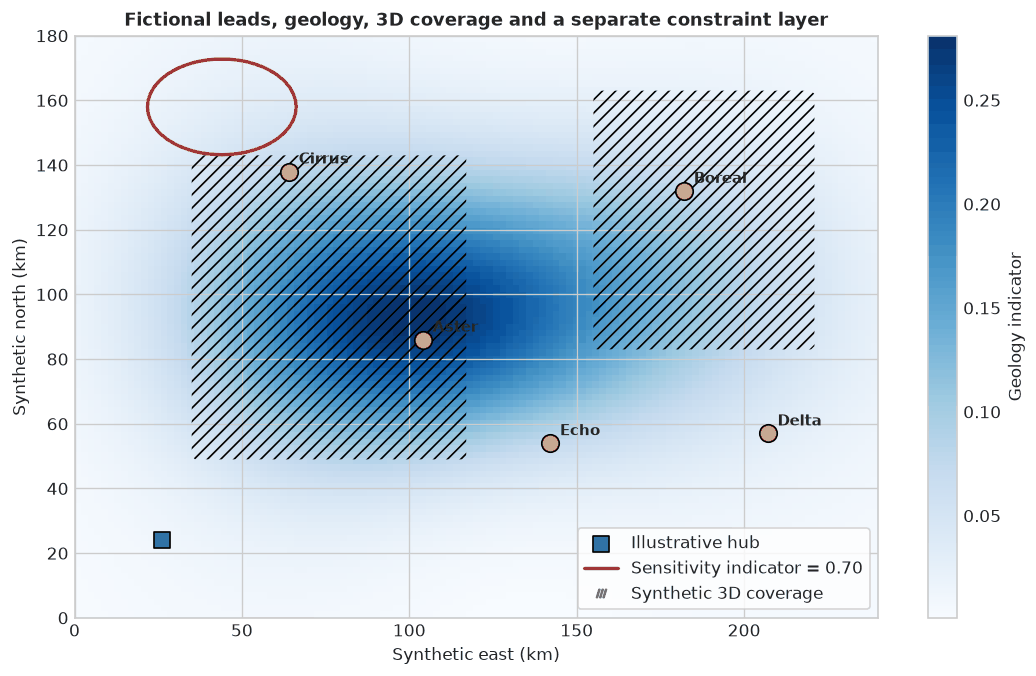

In [17]:
figure, axis = plt.subplots(figsize=(10.8, 6.3))
image = axis.imshow(
    play_probability * seal_chance,
    origin="lower",
    extent=[x_km.min(), x_km.max(), y_km.min(), y_km.max()],
    aspect="auto",
    cmap="Blues",
)
axis.contour(
    x_grid,
    y_grid,
    environmental_sensitivity,
    levels=[0.70],
    colors="#D62728",
    linewidths=2.0,
)
axis.contourf(
    x_grid,
    y_grid,
    three_d_coverage.astype(float),
    levels=[0.5, 1.5],
    colors="none",
    hatches=["///"],
)

for _, row in lead_screen.iterrows():
    axis.scatter(
        row["East (km)"],
        row["North (km)"],
        s=110,
        color="#F4A261",
        edgecolor="black",
        zorder=5,
    )
    axis.text(
        row["East (km)"] + 3.0,
        row["North (km)"] + 2.5,
        row["Lead"],
        fontsize=9,
        fontweight="bold",
    )

axis.scatter(
    infrastructure_x_km,
    infrastructure_y_km,
    marker="s",
    s=100,
    color="#2A9D8F",
    edgecolor="black",
    label="Illustrative hub",
)
axis.plot([], [], color="#D62728", lw=2, label="Sensitivity indicator = 0.70")
axis.plot([], [], color="#666666", lw=0, marker=r"$///$", label="Synthetic 3D coverage")
axis.set_xlabel("Synthetic east (km)")
axis.set_ylabel("Synthetic north (km)")
axis.set_title("Fictional leads, geology, 3D coverage and a separate constraint layer")
axis.legend(loc="lower right")
figure.colorbar(image, ax=axis, label="Geology indicator")
plt.show()

## Where could additional seismic create information value?

A coverage map is not a hydrocarbon map. One transparent acquisition index is
the product of geological promise and the remaining data gap:

$$I_{\mathrm{acquisition}}=I_{\mathrm{geology}}(1-I_{\mathrm{data\ maturity}})$$

It identifies places where a better image could matter. It is **not** an
economic value of information, a permit, or a recommendation to acquire. A
real programme also considers whether uncertainty is actually resolvable,
survey feasibility, licence rights, coexistence, cost, schedule, decision
thresholds, and alternative technologies.

In [18]:
lead_screen["Acquisition information index"] = (
    lead_screen["Geology indicator"] * lead_screen["Data gap"]
)
lead_screen["Access indicator"] = np.exp(
    -lead_screen["Infrastructure distance (km)"] / 180.0
) * np.exp(-lead_screen["Water depth (m)"] / 1800.0)

acquisition_ranking = lead_screen[
    [
        "Lead",
        "Geology indicator",
        "Data maturity",
        "Acquisition information index",
        "Access indicator",
        "Environmental indicator",
        "High-sensitivity flag",
    ]
].sort_values("Acquisition information index", ascending=False)

acquisition_ranking.round(3)

,Lead,Geology indicator,Data maturity,Acquisition information index,Access indicator,Environmental indicator,High-sensitivity flag
0,Aster,0.271,0.734,0.072,0.427,0.082,False
4,Echo,0.074,0.457,0.040,0.373,0.117,False
2,Cirrus,0.079,0.701,0.024,0.383,0.534,False
3,Delta,0.032,0.403,0.019,0.239,0.532,False
1,Boreal,0.077,0.760,0.018,0.221,0.081,False


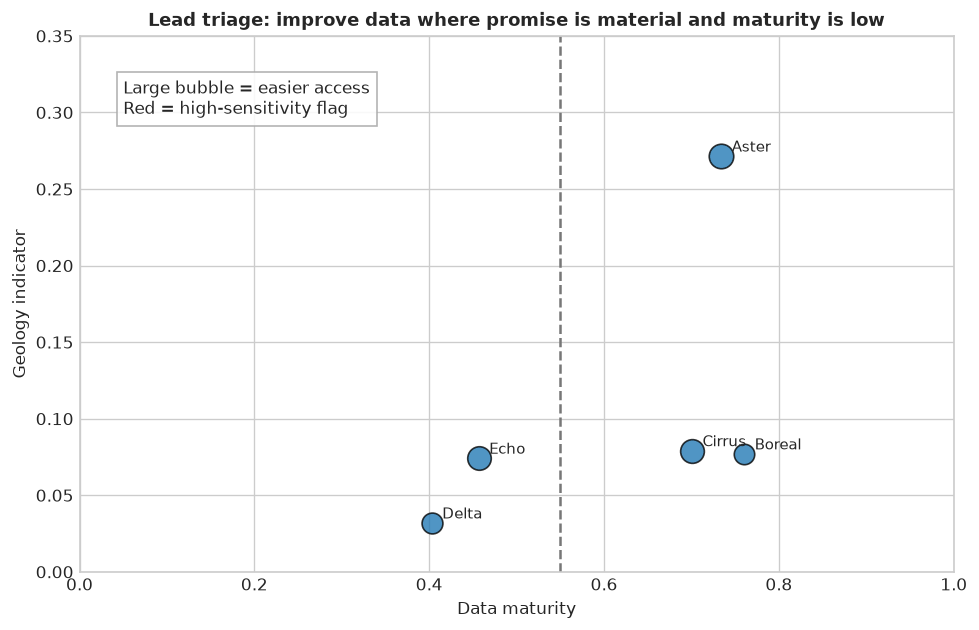

In [19]:
figure, axis = plt.subplots(figsize=(9.4, 5.8))

for _, row in lead_screen.iterrows():
    color = "#D62728" if row["High-sensitivity flag"] else "#1F77B4"
    axis.scatter(
        row["Data maturity"],
        row["Geology indicator"],
        s=80 + 320 * row["Access indicator"],
        color=color,
        alpha=0.78,
        edgecolor="black",
    )
    axis.text(
        row["Data maturity"] + 0.012,
        row["Geology indicator"] + 0.003,
        row["Lead"],
        fontsize=9,
    )

axis.axvline(0.55, color="#777777", linestyle="--")
axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, max(0.35, lead_screen["Geology indicator"].max() * 1.18))
axis.set_xlabel("Data maturity")
axis.set_ylabel("Geology indicator")
axis.set_title("Lead triage: improve data where promise is material and maturity is low")
axis.text(
    0.05,
    axis.get_ylim()[1] * 0.92,
    "Large bubble = easier access\nRed = high-sensitivity flag",
    va="top",
    bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#AAAAAA"},
)
plt.show()

# Part V — Prospect chance: evidence before numbers

For a drillable segment, this notebook follows the six-factor structure in
Milkov (2015): structure, reservoir facies, reservoir deliverability, seal,
mature source, and migration. Under a documented independence approximation:

$$P_{\mathrm{g}}=\prod_{i=1}^{6}P_i$$

The probability values must come from traceable positive, neutral, and
negative evidence—not from adjusting numbers until a preferred answer is
obtained. Dependencies require a different calculation.

The method is informed by:

- Otis and Schneidermann (1997),
  [A Process for Evaluating Exploration Prospects](https://doi.org/10.1306/522B49F1-1727-11D7-8645000102C1865D);
- Milkov (2015),
  [Risk tables for less biased and more consistent estimation of geological success](https://doi.org/10.1016/j.earscirev.2015.08.006); and
- Quirk and Ruthrauff (2008),
  [Toward consistency in petroleum exploration](https://doi.org/10.1306/06040808064).

In [20]:
prospect_factors = pd.DataFrame(
    [
        (
            "Structure",
            0.72,
            "3D closure persists in tested depth conversions",
            "Fault juxtaposition and velocity uncertainty remain",
        ),
        (
            "Reservoir facies",
            0.76,
            "Regional wells and seismic geomorphology support sand",
            "Net-to-gross varies between analogues",
        ),
        (
            "Reservoir deliverability",
            0.83,
            "Analogue porosity and permeability are commonly effective",
            "Diagenetic degradation is incompletely calibrated",
        ),
        (
            "Seal",
            0.84,
            "Regional top seal is present in nearby wells",
            "Local fault-seal behaviour is model-dependent",
        ),
        (
            "Mature source",
            0.82,
            "Basin model and geochemistry support mature source",
            "Kitchen extent is uncertain at the segment edge",
        ),
        (
            "Migration",
            0.79,
            "Mapped carrier system and timing are compatible",
            "Leakage history and fill-spill path are uncertain",
        ),
    ],
    columns=["Risk factor", "Probability", "Supporting evidence", "Residual uncertainty"],
)


def independent_geological_chance(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    if np.any((probabilities < 0.0) | (probabilities > 1.0)):
        raise ValueError("Probabilities must lie between zero and one.")
    return float(np.prod(probabilities))


geological_chance = independent_geological_chance(
    prospect_factors["Probability"]
)
prospect_factors

,Risk factor,Probability,Supporting evidence,Residual uncertainty
0,Structure,0.72,3D closure persists in tested depth conversions,Fault juxtaposition and velocity uncertainty r...
1,Reservoir facies,0.76,Regional wells and seismic geomorphology suppo...,Net-to-gross varies between analogues
2,Reservoir deliverability,0.83,Analogue porosity and permeability are commonl...,Diagenetic degradation is incompletely calibrated
3,Seal,0.84,Regional top seal is present in nearby wells,Local fault-seal behaviour is model-dependent
4,Mature source,0.82,Basin model and geochemistry support mature so...,Kitchen extent is uncertain at the segment edge
5,Migration,0.79,Mapped carrier system and timing are compatible,Leakage history and fill-spill path are uncertain


In [21]:
factor_summary = pd.Series(
    {
        "Prospect": "Aster (synthetic)",
        "Geological chance of success": geological_chance,
        "Geological chance (%)": 100.0 * geological_chance,
        "Lowest factor": prospect_factors.loc[
            prospect_factors["Probability"].idxmin(),
            "Risk factor",
        ],
        "Independence approximation": True,
    },
    name="pre-drill risk statement",
)
factor_summary.to_frame()

,pre-drill risk statement
Prospect,Aster (synthetic)
Geological chance of success,0.247141
Geological chance (%),24.714078
Lowest factor,Structure
Independence approximation,True


## Calibration and probability verification

Probabilities should be checked against outcomes for comparable, genuinely
pre-drill assessments. A simple Beta-binomial illustration updates one play
factor from analogue outcomes. It does not replace geological judgement:
analogue selection, dry-hole definitions, dependencies, and pre-drill
archiving remain critical.

In [22]:
prior_alpha = 6.0
prior_beta = 4.0
analogue_successes = 8
analogue_failures = 5

posterior_alpha = prior_alpha + analogue_successes
posterior_beta = prior_beta + analogue_failures

prior_samples = rng.beta(prior_alpha, prior_beta, size=40_000)
posterior_samples = rng.beta(
    posterior_alpha,
    posterior_beta,
    size=40_000,
)

calibration_update = pd.Series(
    {
        "Prior mean": prior_samples.mean(),
        "Analogue wells": analogue_successes + analogue_failures,
        "Observed analogue fraction": analogue_successes
        / (analogue_successes + analogue_failures),
        "Posterior mean": posterior_samples.mean(),
        "Posterior P90 low": np.quantile(posterior_samples, 0.10),
        "Posterior P10 high": np.quantile(posterior_samples, 0.90),
    },
    name="illustrative factor calibration",
)
calibration_update.to_frame()

,illustrative factor calibration
Prior mean,0.600134
Analogue wells,13.000000
Observed analogue fraction,0.615385
Posterior mean,0.608461
Posterior P90 low,0.476952
Posterior P10 high,0.735874


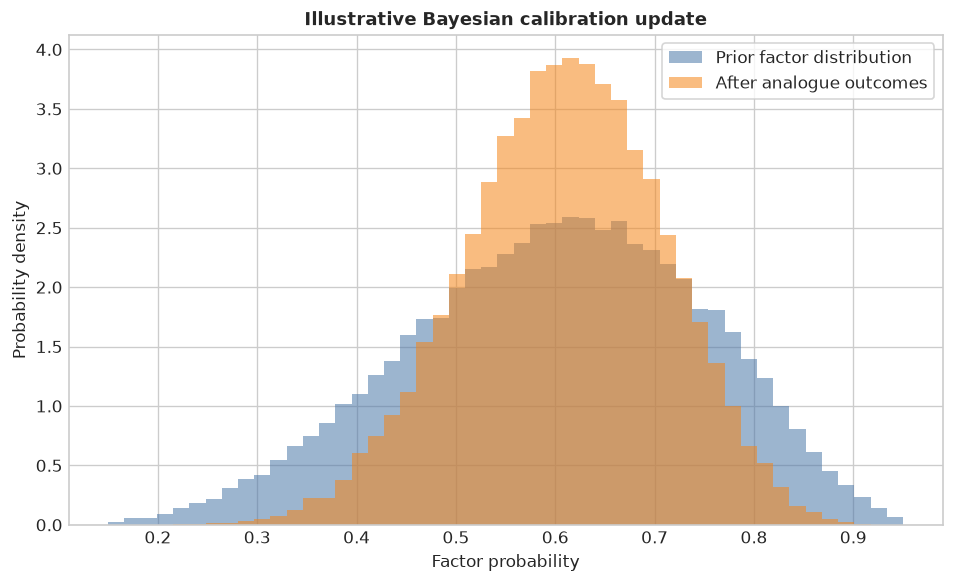

In [23]:
figure, axis = plt.subplots(figsize=(9.4, 5.3))
bins = np.linspace(0.15, 0.95, 50)
axis.hist(
    prior_samples,
    bins=bins,
    density=True,
    alpha=0.55,
    color="#4C78A8",
    label="Prior factor distribution",
)
axis.hist(
    posterior_samples,
    bins=bins,
    density=True,
    alpha=0.55,
    color="#F58518",
    label="After analogue outcomes",
)
axis.set_xlabel("Factor probability")
axis.set_ylabel("Probability density")
axis.set_title("Illustrative Bayesian calibration update")
axis.legend()
plt.show()

# Part VI — Success-case volume and uncertainty

For an oil prospect, a screening stock-tank oil initially in place is:

$$N=\frac{V_{\mathrm{GRV}}\,\mathrm{NTG}\,\phi\,(1-S_{\mathrm{wi}})}{B_{\mathrm{o}}}$$

and recoverable oil is:

$$N_{\mathrm{rec}}=N\,R_{\mathrm{F}}$$

where $V_{\mathrm{GRV}}$ is gross rock volume in m³, $\mathrm{NTG}$ is
net-to-gross, $\phi$ is porosity, $S_{\mathrm{wi}}$ is initial water
saturation, $B_{\mathrm{o}}$ is reservoir m³ per standard m³, and
$R_{\mathrm{F}}$ is the recovery factor.

The distributions below are synthetic and conditional on geological success.
Correlations are omitted deliberately and listed as a limitation.

In [24]:
volume_assumptions = pd.DataFrame(
    [
        ("Gross rock volume", 500.0, 900.0, 1_600.0, "million m³"),
        ("Net-to-gross", 0.45, 0.62, 0.78, "fraction"),
        ("Porosity", 0.16, 0.22, 0.28, "fraction"),
        ("Initial water saturation", 0.18, 0.27, 0.38, "fraction"),
        ("Oil formation volume factor", 1.45, 1.75, 2.10, "rm³/Sm³"),
        ("Recovery factor", 0.25, 0.36, 0.48, "fraction"),
    ],
    columns=["Parameter", "Low", "Mode", "High", "Unit"],
)
volume_assumptions

,Parameter,Low,Mode,High,Unit
0,Gross rock volume,500.00,900.00,1600.00,million m³
1,Net-to-gross,0.45,0.62,0.78,fraction
2,Porosity,0.16,0.22,0.28,fraction
3,Initial water saturation,0.18,0.27,0.38,fraction
4,Oil formation volume factor,1.45,1.75,2.10,rm³/Sm³
5,Recovery factor,0.25,0.36,0.48,fraction


In [25]:
realizations = 50_000


def triangular(parameter_name, scale=1.0):
    row = volume_assumptions.set_index("Parameter").loc[parameter_name]
    return rng.triangular(
        row["Low"],
        row["Mode"],
        row["High"],
        size=realizations,
    ) * scale


volume_samples = pd.DataFrame(
    {
        "Gross rock volume": triangular(
            "Gross rock volume",
            scale=1.0e6,
        ),
        "Net-to-gross": triangular("Net-to-gross"),
        "Porosity": triangular("Porosity"),
        "Initial water saturation": triangular(
            "Initial water saturation"
        ),
        "Oil formation volume factor": triangular(
            "Oil formation volume factor"
        ),
        "Recovery factor": triangular("Recovery factor"),
    }
)

volume_samples["STOIIP (million Sm³)"] = (
    volume_samples["Gross rock volume"]
    * volume_samples["Net-to-gross"]
    * volume_samples["Porosity"]
    * (1.0 - volume_samples["Initial water saturation"])
    / volume_samples["Oil formation volume factor"]
    / 1.0e6
)
volume_samples["Recoverable oil (million Sm³)"] = (
    volume_samples["STOIIP (million Sm³)"]
    * volume_samples["Recovery factor"]
)


def petroleum_percentiles(values):
    values = np.asarray(values)
    return {
        "P90 low": np.quantile(values, 0.10),
        "P50": np.quantile(values, 0.50),
        "Mean": np.mean(values),
        "P10 high": np.quantile(values, 0.90),
    }


volume_summary = pd.DataFrame(
    {
        "STOIIP (million Sm³)": petroleum_percentiles(
            volume_samples["STOIIP (million Sm³)"]
        ),
        "Recoverable oil (million Sm³)": petroleum_percentiles(
            volume_samples["Recoverable oil (million Sm³)"]
        ),
    }
).T
volume_summary.round(2)

,P90 low,P50,Mean,P10 high
STOIIP (million Sm³),36.19,53.97,55.88,78.37
Recoverable oil (million Sm³),12.58,19.40,20.31,29.26


Petroleum volume notation commonly uses exceedance probabilities: P90 is a
low volume exceeded in about 90% of success cases, while P10 is a high volume
exceeded in about 10%. It is therefore calculated here from the 10th and 90th
distribution percentiles, respectively.

In [26]:
risked_success = rng.random(realizations) < geological_chance
risked_recoverable = (
    volume_samples["Recoverable oil (million Sm³)"].to_numpy()
    * risked_success
)

risked_summary = pd.Series(
    {
        "Geological chance": geological_chance,
        "Expected success-case recoverable (million Sm³)": volume_samples[
            "Recoverable oil (million Sm³)"
        ].mean(),
        "Chance-weighted expected recoverable (million Sm³)": (
            risked_recoverable.mean()
        ),
        "Simulated successful realizations": int(risked_success.sum()),
        "Simulated dry realizations": int((~risked_success).sum()),
    },
    name="risk and volume kept separate",
)
risked_summary.to_frame()

,risk and volume kept separate
Geological chance,0.247141
Expected success-case recoverable (million Sm³),20.312939
Chance-weighted expected recoverable (million Sm³),5.043842
Simulated successful realizations,12471.000000
Simulated dry realizations,37529.000000


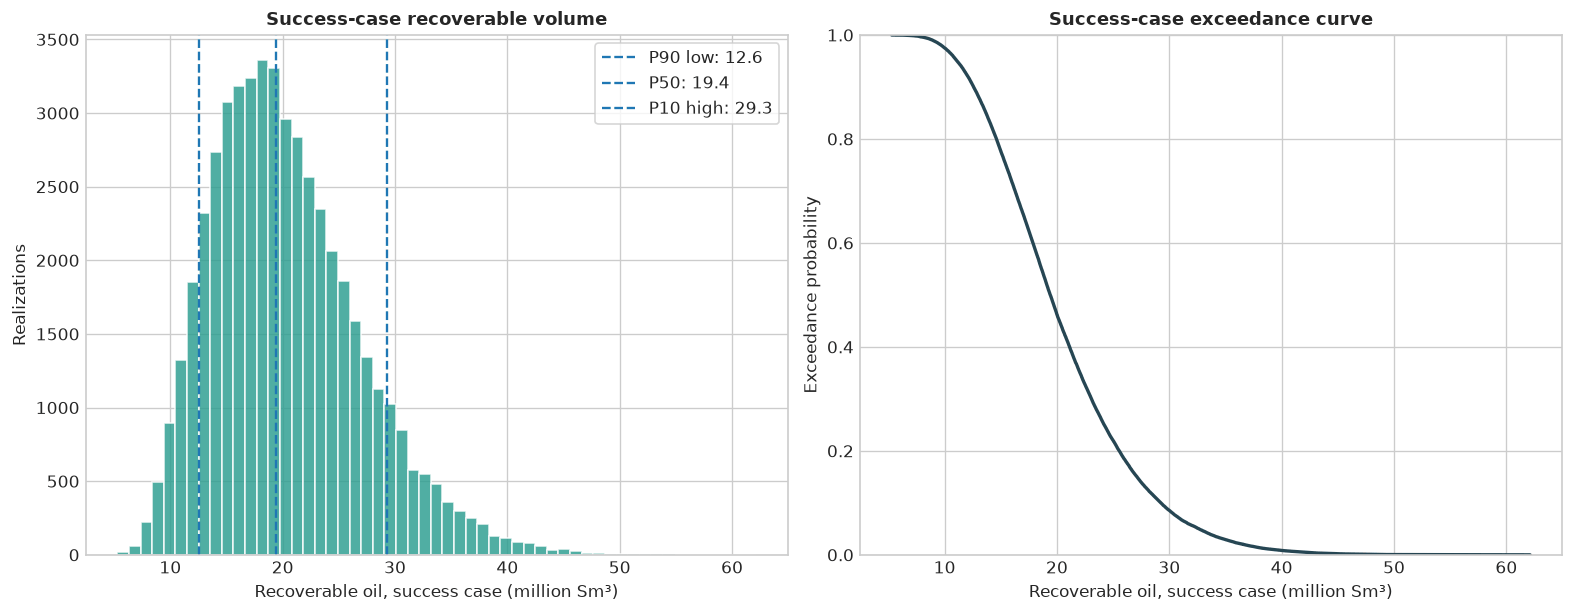

In [27]:
recoverable = volume_samples["Recoverable oil (million Sm³)"]
percentiles = petroleum_percentiles(recoverable)

figure, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)

axes[0].hist(
    recoverable,
    bins=55,
    color="#2A9D8F",
    alpha=0.82,
    edgecolor="white",
)
for label, value in percentiles.items():
    if label == "Mean":
        continue
    axes[0].axvline(value, linestyle="--", linewidth=1.4, label=f"{label}: {value:.1f}")
axes[0].set_xlabel("Recoverable oil, success case (million Sm³)")
axes[0].set_ylabel("Realizations")
axes[0].set_title("Success-case recoverable volume")
axes[0].legend()

sorted_volume = np.sort(recoverable)
exceedance = 1.0 - np.arange(1, realizations + 1) / (realizations + 1)
axes[1].plot(sorted_volume, exceedance, color="#264653", linewidth=2)
axes[1].set_xlabel("Recoverable oil, success case (million Sm³)")
axes[1].set_ylabel("Exceedance probability")
axes[1].set_title("Success-case exceedance curve")
axes[1].set_ylim(0.0, 1.0)

plt.show()

## Which assumptions control volume uncertainty?

Spearman rank correlation is used as a screening sensitivity measure. It
captures monotonic influence, not causal importance and not interactions.

In [28]:
output_column = "Recoverable oil (million Sm³)"
input_columns = [
    "Gross rock volume",
    "Net-to-gross",
    "Porosity",
    "Initial water saturation",
    "Oil formation volume factor",
    "Recovery factor",
]

rank_correlations = pd.Series(
    {
        column: volume_samples[column].rank().corr(
            volume_samples[output_column].rank()
        )
        for column in input_columns
    },
    name="Spearman rank correlation",
).sort_values()

rank_correlations.to_frame()

,Spearman rank correlation
Oil formation volume factor,-0.227411
Initial water saturation,-0.164962
Net-to-gross,0.327150
Porosity,0.335032
Recovery factor,0.392649
Gross rock volume,0.709499


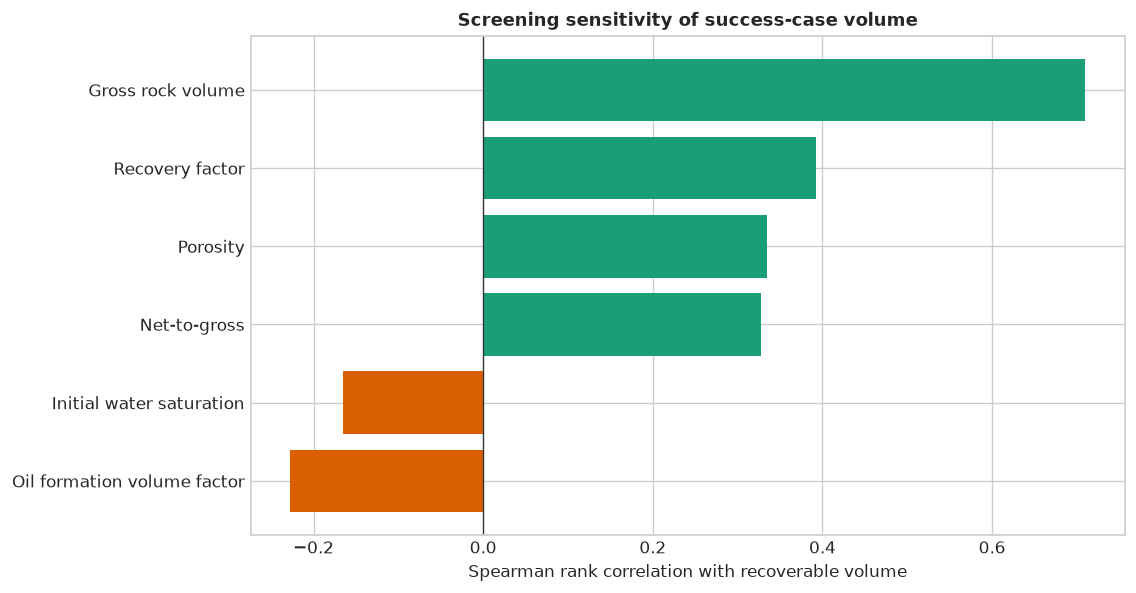

In [29]:
figure, axis = plt.subplots(figsize=(9.4, 5.4))
colors = [
    "#D95F02" if value < 0.0 else "#1B9E77"
    for value in rank_correlations
]
axis.barh(
    rank_correlations.index,
    rank_correlations.values,
    color=colors,
)
axis.axvline(0.0, color="#333333", linewidth=0.8)
axis.set_xlabel("Spearman rank correlation with recoverable volume")
axis.set_title("Screening sensitivity of success-case volume")
plt.show()

# Part VII — A transparent drill screen

Geological success does not guarantee a commercial discovery. The compact
screen below converts recoverable standard volume to barrels and applies a
synthetic post-discovery value per barrel. It then compares expected success
value with an exploration-well cost:

$$\mathrm{EMV}=P_{\mathrm{g}}\,V_{\mathrm{success}}-C_{\mathrm{well}}$$

This is not a full project valuation. It omits tax, timing, appraisal,
development capital, tariffs, capacity, emissions, abandonment, partner
shares, and price scenarios. Those belong downstream in the field-development
workflow.

In [30]:
sm3_to_barrels = 6.28981
net_value_usd_per_barrel = 5.5
exploration_well_cost_musd = 105.0

success_value_musd = (
    recoverable
    * sm3_to_barrels
    * net_value_usd_per_barrel
)
expected_monetary_value_musd = (
    geological_chance * success_value_musd.mean()
    - exploration_well_cost_musd
)
break_even_geological_chance = (
    exploration_well_cost_musd / success_value_musd.mean()
)

decision_screen = pd.Series(
    {
        "Mean success value (MUSD)": success_value_musd.mean(),
        "Exploration well cost (MUSD)": exploration_well_cost_musd,
        "Geological chance": geological_chance,
        "Break-even geological chance": break_even_geological_chance,
        "Screening EMV (MUSD)": expected_monetary_value_musd,
        "Synthetic decision": (
            "progress to integrated review"
            if expected_monetary_value_musd > 0.0
            else "do not drill on this screen"
        ),
    },
    name="illustrative pre-drill screen",
)
decision_screen.to_frame()

,illustrative pre-drill screen
Mean success value (MUSD),702.704888
Exploration well cost (MUSD),105.0
Geological chance,0.247141
Break-even geological chance,0.149423
Screening EMV (MUSD),68.667033
Synthetic decision,progress to integrated review


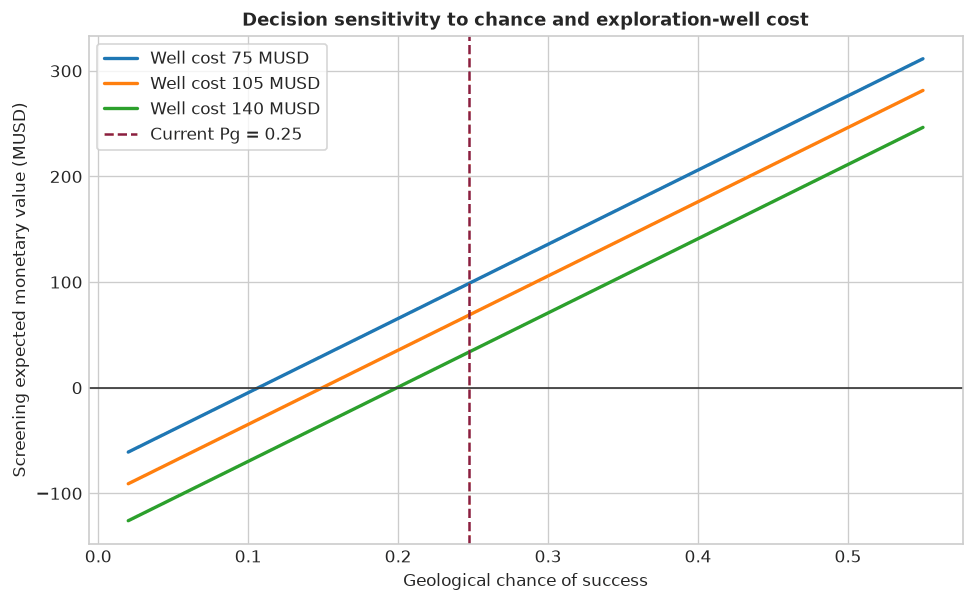

In [31]:
chance_axis = np.linspace(0.02, 0.55, 160)
well_cost_cases = [75.0, 105.0, 140.0]

figure, axis = plt.subplots(figsize=(9.4, 5.5))
for well_cost in well_cost_cases:
    emv_curve = chance_axis * success_value_musd.mean() - well_cost
    axis.plot(
        chance_axis,
        emv_curve,
        linewidth=2,
        label=f"Well cost {well_cost:.0f} MUSD",
    )

axis.axhline(0.0, color="#333333", linewidth=1.0)
axis.axvline(
    geological_chance,
    color="#8B1E3F",
    linestyle="--",
    label=f"Current Pg = {geological_chance:.2f}",
)
axis.set_xlabel("Geological chance of success")
axis.set_ylabel("Screening expected monetary value (MUSD)")
axis.set_title("Decision sensitivity to chance and exploration-well cost")
axis.legend()
plt.show()

# Part VIII — Discovery: replace analogues with measured fluid evidence

Suppose the Aster wildcat encounters movable hydrocarbons and retrieves a
representative, uncontaminated fluid sample. The synthetic composition below
is flashed with NeqSim using the Peng–Robinson equation of state and the
classic mixing rule.

The calculation connects exploration evidence to field development:

1. reservoir-condition phase and density;
2. stock-tank gas and liquid after a standard-condition flash;
3. an initial oil formation-volume factor $B_{\mathrm{o}}$; and
4. an initial solution gas–oil ratio.

A real study must validate sampling quality, recombine separator samples when
needed, characterize the heavy fraction, select/tune an appropriate
thermodynamic model, and match laboratory CCE, DLE, separator, viscosity, and
swelling data before simulator export.

In [32]:
discovery_composition = {
    "nitrogen": 0.008,
    "CO2": 0.018,
    "methane": 0.420,
    "ethane": 0.080,
    "propane": 0.070,
    "i-butane": 0.025,
    "n-butane": 0.040,
    "i-pentane": 0.020,
    "n-pentane": 0.025,
    "n-hexane": 0.055,
    "n-heptane": 0.080,
    "n-octane": 0.070,
    "n-nonane": 0.045,
    "nC10": 0.044,
}

composition_table = pd.Series(
    discovery_composition,
    name="Mole fraction",
).to_frame()
composition_table.loc["Total"] = composition_table["Mole fraction"].sum()
composition_table

,Mole fraction
nitrogen,0.008
CO2,0.018
methane,0.420
ethane,0.080
propane,0.070
i-butane,0.025
n-butane,0.040
i-pentane,0.020
n-pentane,0.025
n-hexane,0.055


In [33]:
discovery_fluid = fluid("pr")

for component_name, mole_fraction in discovery_composition.items():
    discovery_fluid.addComponent(component_name, mole_fraction)

discovery_fluid.setMixingRule("classic")
discovery_fluid.setMultiPhaseCheck(True)

reservoir_temperature_c = 95.0
reservoir_pressure_bara = 260.0
standard_temperature_c = 15.0
standard_pressure_bara = 1.01325

reservoir_fluid = discovery_fluid.clone()
reservoir_fluid.setTemperature(reservoir_temperature_c, "C")
reservoir_fluid.setPressure(reservoir_pressure_bara, "bara")
TPflash(reservoir_fluid)
reservoir_fluid.initPhysicalProperties()

standard_fluid = discovery_fluid.clone()
standard_fluid.setTemperature(standard_temperature_c, "C")
standard_fluid.setPressure(standard_pressure_bara, "bara")
TPflash(standard_fluid)
standard_fluid.initPhysicalProperties()


def phase_index_by_name(system, requested_name):
    for phase_index in range(system.getNumberOfPhases()):
        phase_name = str(
            system.getPhase(phase_index).getPhaseTypeName()
        ).lower()
        if phase_name == requested_name.lower():
            return phase_index
    raise ValueError(f"No {requested_name} phase was found.")


reservoir_oil_index = phase_index_by_name(reservoir_fluid, "oil")
stock_tank_oil_index = phase_index_by_name(standard_fluid, "oil")
stock_tank_gas_index = phase_index_by_name(standard_fluid, "gas")

reservoir_oil = reservoir_fluid.getPhase(reservoir_oil_index)
stock_tank_oil = standard_fluid.getPhase(stock_tank_oil_index)
stock_tank_gas = standard_fluid.getPhase(stock_tank_gas_index)

reservoir_oil_volume_m3 = reservoir_oil.getVolume("m3")
stock_tank_oil_volume_sm3 = stock_tank_oil.getVolume("m3")
stock_tank_gas_volume_sm3 = stock_tank_gas.getVolume("m3")

neqsim_bo = reservoir_oil_volume_m3 / stock_tank_oil_volume_sm3
neqsim_solution_gor = (
    stock_tank_gas_volume_sm3 / stock_tank_oil_volume_sm3
)

fluid_screen = pd.Series(
    {
        "EOS": "Peng–Robinson",
        "Mixing rule": "classic",
        "Reservoir temperature (°C)": reservoir_temperature_c,
        "Reservoir pressure (bara)": reservoir_pressure_bara,
        "Reservoir phases": reservoir_fluid.getNumberOfPhases(),
        "Reservoir oil density (kg/m³)": reservoir_oil.getDensity(
            "kg/m3"
        ),
        "Standard phases": standard_fluid.getNumberOfPhases(),
        "Initial Bo (rm³/Sm³)": neqsim_bo,
        "Initial solution GOR (Sm³/Sm³)": neqsim_solution_gor,
    },
    name="hypothetical discovery-fluid screen",
)
fluid_screen.to_frame()

,hypothetical discovery-fluid screen
EOS,Peng–Robinson
Mixing rule,classic
Reservoir temperature (°C),95.0
Reservoir pressure (bara),260.0
Reservoir phases,1
Reservoir oil density (kg/m³),499.336325
Standard phases,2
Initial Bo (rm³/Sm³),2.097972
Initial solution GOR (Sm³/Sm³),326.447689


## Close the loop: update the prospect volume model

The pre-drill analogue used a triangular $B_{\mathrm{o}}$ distribution with a
mode of 1.75 rm³/Sm³. The hypothetical NeqSim sample gives an initial
single-point estimate. The comparison shows why fluid acquisition can change
the standard-volume and facility basis even when the mapped rock volume is
unchanged.

In [34]:
sample_updated_recoverable = (
    volume_samples["Gross rock volume"]
    * volume_samples["Net-to-gross"]
    * volume_samples["Porosity"]
    * (1.0 - volume_samples["Initial water saturation"])
    / neqsim_bo
    * volume_samples["Recovery factor"]
    / 1.0e6
)

fluid_update_summary = pd.DataFrame(
    {
        "Pre-drill analogue Bo distribution": petroleum_percentiles(
            recoverable
        ),
        "Hypothetical sample Bo point estimate": petroleum_percentiles(
            sample_updated_recoverable
        ),
    }
).T
fluid_update_summary.round(2)

,P90 low,P50,Mean,P10 high
Pre-drill analogue Bo distribution,12.58,19.4,20.31,29.26
Hypothetical sample Bo point estimate,10.71,16.3,17.00,24.29


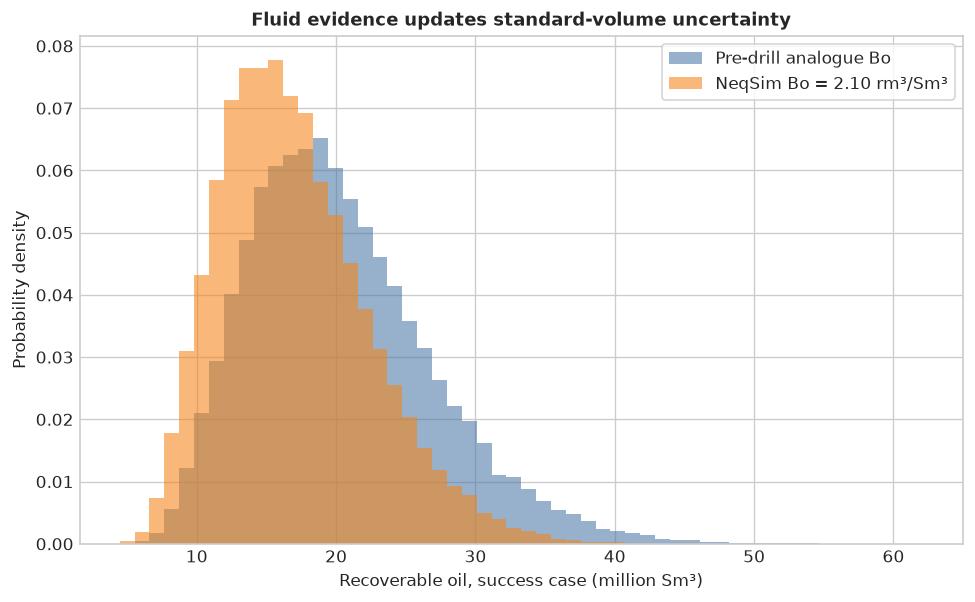

In [35]:
figure, axis = plt.subplots(figsize=(9.5, 5.5))
bins = np.linspace(
    min(recoverable.min(), sample_updated_recoverable.min()),
    max(recoverable.max(), sample_updated_recoverable.max()),
    55,
)
axis.hist(
    recoverable,
    bins=bins,
    density=True,
    alpha=0.58,
    color="#4C78A8",
    label="Pre-drill analogue Bo",
)
axis.hist(
    sample_updated_recoverable,
    bins=bins,
    density=True,
    alpha=0.58,
    color="#F58518",
    label=f"NeqSim Bo = {neqsim_bo:.2f} rm³/Sm³",
)
axis.set_xlabel("Recoverable oil, success case (million Sm³)")
axis.set_ylabel("Probability density")
axis.set_title("Fluid evidence updates standard-volume uncertainty")
axis.legend()
plt.show()

# Part IX — What makes a discovery ready for the next notebook?

A discovery is not yet a field, reserve, production licence extension, PDO,
facility concept, or production forecast. The wildcat result starts a new
uncertainty-reduction loop.

The Directorate requires a final well report for all wells and a discovery
evaluation report for discovery wells; see
[Final reports and discovery evaluation](https://www.sodir.no/en/regulations/reporting_and_applications/wells/final-reports-and-discovery-evaluation/).
The licence group must also satisfy its specific work programme and decide
whether appraisal and development studies are justified.

In [36]:
discovery_handoff = pd.DataFrame(
    [
        (
            "Structure",
            "Depth maps, faults, velocity model and spill point",
            "GRV and compartment uncertainty",
        ),
        (
            "Petrophysics",
            "Raw/processed logs, saturation and cut-offs",
            "Net pay, porosity and saturation",
        ),
        ("Rock", "Core, SCAL/RCAL, mineralogy and geomechanics", "Flow functions and well design"),
        (
            "Pressure",
            "Formation pressure, gradients and contacts",
            "Connectivity and fluid contacts",
        ),
        (
            "Fluid",
            "Sample provenance, composition and PVT experiments",
            "EOS, Bo, GOR, density and phase behaviour",
        ),
        (
            "Deliverability",
            "DST/mini-DST, mobility and skin evidence",
            "Well productivity and completion basis",
        ),
        (
            "Volumes",
            "Low/base/high or probabilistic in-place volumes",
            "Discovery range with dependencies",
        ),
        (
            "Uncertainty",
            "Alternative interpretations and correlations",
            "Appraisal value-of-information plan",
        ),
        ("HSE/environment", "Hazards, shallow data and constraints", "Safe appraisal planning"),
        (
            "Reporting",
            "Final well and discovery evaluation records",
            "Authority and Diskos obligations",
        ),
    ],
    columns=["Data domain", "Minimum hand-off", "Downstream use"],
)
discovery_handoff

,Data domain,Minimum hand-off,Downstream use
0,Structure,"Depth maps, faults, velocity model and spill p...",GRV and compartment uncertainty
1,Petrophysics,"Raw/processed logs, saturation and cut-offs","Net pay, porosity and saturation"
2,Rock,"Core, SCAL/RCAL, mineralogy and geomechanics",Flow functions and well design
3,Pressure,"Formation pressure, gradients and contacts",Connectivity and fluid contacts
4,Fluid,"Sample provenance, composition and PVT experim...","EOS, Bo, GOR, density and phase behaviour"
5,Deliverability,"DST/mini-DST, mobility and skin evidence",Well productivity and completion basis
6,Volumes,Low/base/high or probabilistic in-place volumes,Discovery range with dependencies
7,Uncertainty,Alternative interpretations and correlations,Appraisal value-of-information plan
8,HSE/environment,"Hazards, shallow data and constraints",Safe appraisal planning
9,Reporting,Final well and discovery evaluation records,Authority and Diskos obligations


## Continue the end-to-end NeqSim learning path

1. **This notebook:** opening → access → licence work → prospect → wildcat →
   discovery.
2. **Next:** [From seismic, samples, and petrophysics to an OPM Flow
   production forecast](../reservoir/subsurface_data_to_opm_flow_production_forecast.ipynb).
3. **Integrated reservoir/process uncertainty:** [ERT + NeqSim integrated
   field-development uncertainty](../reservoir/ert_neqsim_integrated_field_development.ipynb).
4. **Facility concept:** [Offshore facility concept selection with
   NeqSim](offshore_facility_concept_selection_with_neqsim.ipynb).
5. **Lifecycle context:** [Field Development and Operations
   book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html).

This structure keeps the new notebook upstream of detailed seismic,
petrophysics, geological modelling, reservoir simulation, wells, SURF,
process, facilities, economics, and production forecasting.

# Part X — Validation

The checks below test software consistency and defensible bounds. They do not
validate the synthetic prospect against a real subsurface interpretation.

In [37]:
checks = {
    "runtime uses validated NeqSim version": version("neqsim") == "3.16.0",
    "composition closes to one": np.isclose(
        sum(discovery_composition.values()),
        1.0,
        atol=1.0e-12,
    ),
    "all mapped chances are bounded": all(
        np.all((layer >= 0.0) & (layer <= 1.0))
        for layer in [
            source_chance,
            reservoir_chance,
            trap_chance,
            seal_chance,
            data_maturity,
            environmental_sensitivity,
        ]
    ),
    "play probability is bounded": np.all(
        (play_probability >= 0.0) & (play_probability <= 1.0)
    ),
    "five leads are evaluated": len(lead_screen) == 5,
    "lead values are finite": np.isfinite(
        lead_screen.select_dtypes(include=[np.number])
    ).all().all(),
    "constraints are separate from geology": (
        "Environmental indicator" in lead_screen
        and "Geology indicator" in lead_screen
    ),
    "prospect factors are bounded": prospect_factors[
        "Probability"
    ].between(0.0, 1.0).all(),
    "geological chance equals factor product": np.isclose(
        geological_chance,
        prospect_factors["Probability"].prod(),
    ),
    "geological chance is material but below one": (
        0.05 < geological_chance < 0.60
    ),
    "Monte Carlo sample count is complete": len(volume_samples)
    == realizations,
    "STOIIP values are positive": (
        volume_samples["STOIIP (million Sm³)"] > 0.0
    ).all(),
    "recoverable volume does not exceed STOIIP": (
        volume_samples["Recoverable oil (million Sm³)"]
        < volume_samples["STOIIP (million Sm³)"]
    ).all(),
    "petroleum percentiles are ordered": (
        percentiles["P90 low"]
        < percentiles["P50"]
        < percentiles["P10 high"]
    ),
    "risked expectation matches analytical scale": np.isclose(
        risked_recoverable.mean(),
        geological_chance * recoverable.mean(),
        rtol=0.03,
    ),
    "reservoir sample is single phase": (
        reservoir_fluid.getNumberOfPhases() == 1
    ),
    "standard flash separates gas and oil": (
        standard_fluid.getNumberOfPhases() == 2
    ),
    "reservoir density is plausible": (
        350.0 < reservoir_oil.getDensity("kg/m3") < 850.0
    ),
    "NeqSim Bo is plausible": 1.0 < neqsim_bo < 3.5,
    "solution GOR is plausible": 20.0 < neqsim_solution_gor < 800.0,
    "discovery hand-off is complete": len(discovery_handoff) >= 9,
}

validation = pd.DataFrame(
    {
        "Check": list(checks),
        "Passed": list(checks.values()),
    }
)

if not validation["Passed"].all():
    failed = validation.loc[~validation["Passed"], "Check"].tolist()
    raise AssertionError(f"Validation failed: {failed}")

validation

,Check,Passed
0,runtime uses validated NeqSim version,True
1,composition closes to one,True
2,all mapped chances are bounded,True
3,play probability is bounded,True
4,five leads are evaluated,True
5,lead values are finite,True
6,constraints are separate from geology,True
7,prospect factors are bounded,True
8,geological chance equals factor product,True
9,geological chance is material but below one,True


In [38]:
validation_summary = pd.Series(
    {
        "Named checks passed": int(validation["Passed"].sum()),
        "Named checks failed": int((~validation["Passed"]).sum()),
        "Figures retained": 11,
        "Synthetic Monte Carlo realizations": realizations,
        "NeqSim model": "Peng–Robinson / classic mixing rule",
        "Evidence level": (
            "analytical identities, probability bounds, Monte Carlo "
            "consistency and thermodynamic plausibility"
        ),
    },
    name="saved-notebook validation",
)
validation_summary.to_frame()

,saved-notebook validation
Named checks passed,21
Named checks failed,0
Figures retained,11
Synthetic Monte Carlo realizations,50000
NeqSim model,Peng–Robinson / classic mixing rule
Evidence level,"analytical identities, probability bounds, Mon..."


# Interpretation, limitations, and exercises

## Main interpretation

- Norway's **opening**, **licensing**, and **well approval** decisions are
  different gates with different evidence and actors.
- Companies obtain exclusive rights through awarded production licences,
  normally as licence groups with an operator and a binding work programme.
- A promising play map is not yet a prospect. A prospect needs traceable
  evidence, chance, volumes, dependencies, uncertainty, and a drillable target.
- MCS or public seismic coverage measures data availability, not hydrocarbon
  presence. The highest information priority can be a promising but
  under-imaged area.
- Geological chance, success-case volume, access, environmental constraints,
  and economics answer different questions and should not be collapsed into
  one unexplained score.
- Discovery fluid data can materially update standard volumes and the
  downstream process basis. NeqSim provides the bridge from samples and PVT
  evidence to reservoir, well, process, and export calculations.

## Important limitations

1. Every map and prospect number is synthetic; no real NCS ranking is made.
2. The probability product assumes suitable conditional independence.
   Correlated risks require an explicit dependency model.
3. Volumetric input correlations and depth-map structural uncertainty are
   omitted.
4. The MCS index is a prioritisation heuristic, not economic value of
   information.
5. Infrastructure distance does not prove capacity, access, pressure,
   composition compatibility, tariffs, or tie-in feasibility.
6. The environmental indicator is not an impact assessment, management-plan
   condition, consent, or survey constraint.
7. The fluid is synthetic and untuned. One sample flash cannot replace a
   laboratory PVT programme.
8. The EMV screen is pre-tax and omits most field-development cash flows.
9. Current licensing invitations, laws, regulations, map layers, release
   status, and licence terms must be rechecked for real work.

## Suggested exercises

1. Download current public SODIR well, discovery, facility, pipeline, survey,
   and licence files and build a dated, CRS-checked map for one opened area.
2. Compare a numbered-round case with an APA near-infrastructure case without
   using one blended ranking score.
3. Replace one risk-factor probability with a documented evidence table and
   test dependence on another factor.
4. Add correlated gross rock volume, net-to-gross, and recovery-factor
   distributions.
5. Calculate an explicit expected value of sample information for seismic
   reprocessing, new 3D seismic, or an appraisal well.
6. Replace the synthetic composition with an authorized public fluid example,
   add CCE/DLE/separator validation, and export PVT to OPM Flow.
7. Pass the low/base/high discovery package into the next OPM Flow notebook
   and then into a NeqSim well, SURF, and topside capacity study.

## References and current official sources

### Norwegian framework and data

- Norwegian Offshore Directorate,
  [Petroleum Act](https://www.sodir.no/en/regulations/acts/act-29-november-1996-no2.-72-relating-to-petroleum-activities).
- Norwegian Offshore Directorate,
  [Petroleum Regulations](https://www.sodir.no/en/regulations/regulations/petroleum-activities/).
- Norwegian Offshore Directorate,
  [Licensing rounds](https://www.sodir.no/en/facts/production-licences/licensing-rounds/).
- Norwegian Offshore Directorate,
  [Pre-qualification requirements](https://www.sodir.no/en/facts/production-licences/pre-qualification/requirements-for-new-players-on-the-norwegian-continental-shelf/).
- Norwegian Offshore Directorate,
  [Work commitments](https://www.sodir.no/en/regulations/reporting_and_applications/work-commitments/).
- Norwegian Offshore Directorate,
  [Open data](https://www.sodir.no/en/facts/data-and-analyses/open-data/),
  [FactPages](https://factpages.sodir.no/), and
  [FactMaps](https://factmaps.sodir.no/).
- Norwegian Offshore Directorate,
  [Access to released Diskos data](https://www.sodir.no/en/facts/data-and-analyses/release-of-data/access-to-released-data/).
- Norwegian Offshore Directorate,
  [Plays](https://www.sodir.no/en/facts/plays/) and
  [Resource Report 2024](https://www.sodir.no/en/whats-new/publications/reports/resource-report/resource-report-2024/remaining-resources/).
- Norwegian Offshore Directorate,
  [Final reports and discovery evaluation](https://www.sodir.no/en/regulations/reporting_and_applications/wells/final-reports-and-discovery-evaluation/).
- Ministry of Energy / Norwegian Offshore Directorate,
  [APA 2026 invitation](https://www.sodir.no/en/facts/production-licences/licensing-rounds/apa-2026/invitation-to-apply-for-petroleum-production-licence/),
  used only as a dated example of current application structure.

### Scientific and engineering basis

- Otis, R. M. and Schneidermann, N. (1997). *A Process for
  Evaluating Exploration Prospects*. AAPG Bulletin 81(7), 1087–1109.
  [doi:10.1306/522B49F1-1727-11D7-8645000102C1865D](https://doi.org/10.1306/522B49F1-1727-11D7-8645000102C1865D).
- Milkov, A. V. (2015). *Risk tables for less biased and more
  consistent estimation of probability of geological success*. Earth-Science
  Reviews 150, 453–476.
  [doi:10.1016/j.earscirev.2015.08.006](https://doi.org/10.1016/j.earscirev.2015.08.006).
- Quirk, D. G. and Ruthrauff, R. G. (2008). *Toward consistency in
  petroleum exploration: A systematic way of constraining uncertainty in
  prospect volumetrics*. AAPG Bulletin 92(10), 1263–1291.
  [doi:10.1306/06040808064](https://doi.org/10.1306/06040808064).
- Suslick, S. B., Schiozer, D. and Rodriguez, M. R. (2009).
  *Uncertainty and Risk Analysis in Petroleum Exploration and Production*.
  Terræ 6(1), 30–41.
- Equinor / NeqSim,
  [Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html).

**Source status:** framework and links checked 30 July 2026. Always use the
current round invitation, licence document, legislation, and authoritative map
metadata for real work.